This notebook attemps to replicate the analysis done in NPS's climate future project for various levels of downscaled CMIP6 data

In [28]:
import pandas as pd
import numpy as np

import xarray as xr
import geopandas as gpd
import rioxarray as rxr
from shapely.geometry import mapping
import matplotlib.pyplot as plt

In [2]:
# Load the dataset and inspect its structure
nc = xr.open_dataset('isimip/data/processed/gfdl-esm4_r1i1p1f1_w5e5_historical_pr_jotr_monthly.nc', engine="netcdf4")
nc

<xarray.Dataset> Size: 95kB
Dimensions:    (time: 1980, bnds: 2, lon: 3, lat: 2)
Coordinates:
  * time       (time) datetime64[ns] 16kB 1850-01-16 ... 2014-12-16
  * lon        (lon) float64 24B -116.2 -115.8 -115.2
  * lat        (lat) float64 16B 34.25 33.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 32kB ...
    pr         (time, lat, lon) float32 48kB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...
    history:      Fri Jan 30 17:40:16 2026: cdo mergetime gfdl-esm4_r1i1p1f1_...
    frequency:    mon
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

In [3]:
# crop to only pixels inside park boundary

def crop_to_park_boundary(nc, boundary, variable):
    ''' Takes an xarray object and crops within the provided boundary (geopandas), 
    returning a clipped xarray object. '''
    
    # Select just the precipitation variable (time_bnds doesn't have spatial dims)
    nc_pr = nc[variable].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    nc_pr = nc_pr.rio.write_crs("EPSG:4326", inplace=True)
    if nc_pr.rio.crs != boundary.crs:
        boundary = boundary.to_crs(nc_pr.rio.crs)
    nc_clipped = nc_pr.rio.clip(boundary.geometry.values, boundary.crs, drop=True, all_touched=True)

    return(nc_clipped)

def calculate_anomaly(scenario, baseline_period, model, variable, boundary):
    ''' Takes a clipped xarray object and calculates the anomaly relative to the provided baseline period. 
    Returns an xarray object of the anomaly. '''
    nc = xr.open_dataset(f'isimip/data/processed/{model}_w5e5_{scenario}_{variable}_jotr_monthly.nc', engine="netcdf4")
    nc_clipped = crop_to_park_boundary(nc, boundary, variable)
    nc_hist = xr.open_dataset(f'isimip/data/processed/{model}_w5e5_historical_{variable}_jotr_monthly.nc', engine="netcdf4")
    nc_hist_clipped = crop_to_park_boundary(nc_hist, boundary, variable)
    ts_hist = nc_hist_clipped.mean(("lon", "lat"))
    baseline = ts_hist.sel(time=slice(baseline_period[0], baseline_period[1])).mean("time")
    anomaly = nc_clipped.mean(("lon", "lat")) - baseline
    return(anomaly)

# spatially aggregate to average yearly timeseries
def plot_clipped_timeseries(ax, scenario, model, boundary, variable):

    if scenario == "historical":
        color = "blue"
    elif scenario == "ssp126":
        color = "orange"
    elif scenario == "ssp585":
        color = "red"

    try:
        anomaly = calculate_anomaly(scenario, ("1979", "2012"), model, variable, boundary)
        
        anomaly.plot(ax=ax, label=f"{model.split('_')[0]} {scenario}", color=color, alpha=0.7)
    except FileNotFoundError:
        print(f"File not found: {model} {scenario}")

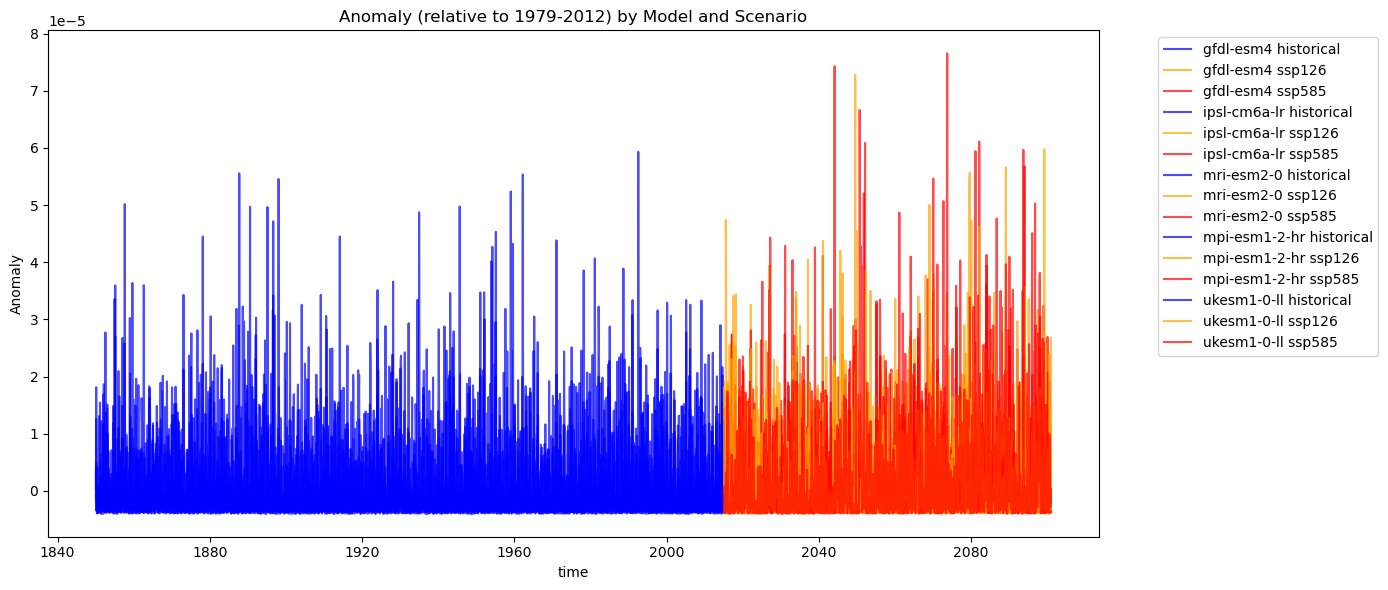

In [5]:
boundary = gpd.read_file('isimip/data/Joshua_Tree_National_Park.shp')

fig, ax = plt.subplots(figsize=(14, 6))

for model in ['gfdl-esm4_r1i1p1f1', 'ipsl-cm6a-lr_r1i1p1f1', 'mri-esm2-0_r1i1p1f1', 'mpi-esm1-2-hr_r1i1p1f1', 'ukesm1-0-ll_r1i1p1f2']:
    for scenario in ["historical", "ssp126", "ssp585"]:
        plot_clipped_timeseries(ax, scenario, model, boundary, 'pr')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Anomaly (relative to 1979-2012) by Model and Scenario')
ax.set_ylabel('Anomaly')
plt.tight_layout()
plt.show()

In [6]:
#Calculate mid-century anomalies

def mid_century_anomalies(scenario, model, variable, boundary):
    anomaly = calculate_anomaly(scenario, ("1979", "2012"), model, variable, boundary)
    mid_century_anomaly = anomaly.sel(time=slice("2035", "2065")).mean("time")
    return(mid_century_anomaly)

mid_century_anomalies("ssp585", "gfdl-esm4_r1i1p1f1", 'pr', boundary)




<xarray.DataArray 'pr' ()> Size: 8B
array(-6.51392469e-07)
Coordinates:
    spatial_ref  int64 8B 0

In [70]:
boundary = gpd.read_file('isimip/data/Joshua_Tree_National_Park.shp')

park = 'jotr'
all_data = []

for model in ['ukesm1-0-ll_r1i1p1f2', 'gfdl-esm4_r1i1p1f1', 'ipsl-cm6a-lr_r1i1p1f1', 'mri-esm2-0_r1i1p1f1', 'mpi-esm1-2-hr_r1i1p1f1']:
    for scenario in ['ssp126',  'ssp370', 'ssp585']:
        anomaly_tas = mid_century_anomalies(scenario, model, 'tas', boundary)
        anomaly_pr = mid_century_anomalies(scenario, model, 'pr', boundary)
        data = {
            'model': model,
            'scenario': scenario,
            'park': park,
            'anomaly_tas': anomaly_tas.item(),
            'anomaly_pr': anomaly_pr.item()
        }

        all_data.append(data)

df = pd.DataFrame(all_data)

print(df.head())

df.to_csv(f'climate_future_{park}.csv')


FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/climate_data_pipeline/isimip/data/processed/ukesm1-0-ll_r1i1p1f2_w5e5_ssp370_pr_jotr_monthly.nc'

In [37]:
park = 'jotr'

df = pd.read_csv(f'climate_future_{park}.csv')

#calculate the 25th and 75th percentile
# assign scenarios outside those percentile a quadrant (warm-hot, dry-wet)
quantiles = df[['anomaly_tas', 'anomaly_pr']].quantile([0.25, 0.5, 0.75])
print(quantiles)
quantiles.iat[0,0]

conditions = [ 
   # warm-dry
   ((df['anomaly_tas'] < quantiles.loc[0.25, 'anomaly_tas']) & (df['anomaly_pr'] < quantiles.loc[0.50, 'anomaly_pr'])) | 
   ((df['anomaly_tas'] < quantiles.loc[0.50, 'anomaly_tas']) & (df['anomaly_pr'] < quantiles.loc[0.25, 'anomaly_pr'])),
   # warm-wet
   ((df['anomaly_tas'] < quantiles.loc[0.25, 'anomaly_tas']) & (df['anomaly_pr'] > quantiles.loc[0.50, 'anomaly_pr'])) | 
   ((df['anomaly_tas'] < quantiles.loc[0.50, 'anomaly_tas']) & (df['anomaly_pr'] > quantiles.loc[0.75, 'anomaly_pr'])),
   # hot-dry
   ((df['anomaly_tas'] > quantiles.loc[0.75, 'anomaly_tas']) & (df['anomaly_pr'] < quantiles.loc[0.50, 'anomaly_pr'])) | 
   ((df['anomaly_tas'] > quantiles.loc[0.50, 'anomaly_tas']) & (df['anomaly_pr'] < quantiles.loc[0.25, 'anomaly_pr'])),
   # hot-wet
   ((df['anomaly_tas'] > quantiles.loc[0.75, 'anomaly_tas']) & (df['anomaly_pr'] > quantiles.loc[0.50, 'anomaly_pr'])) | 
   ((df['anomaly_tas'] > quantiles.loc[0.50, 'anomaly_tas']) & (df['anomaly_pr'] > quantiles.loc[0.75, 'anomaly_pr']))
]

future = ['warm-dry', 'warm-wet', 'hot-dry', 'hot-wet']

df['climate_future'] = np.select(conditions, future, default = 'central')
print(df)


      anomaly_tas    anomaly_pr
0.25     1.657370 -2.860522e-07
0.50     2.032021 -1.014664e-07
0.75     2.496494  4.237618e-07
   Unnamed: 0                   model scenario  park  anomaly_tas  \
0           0    ukesm1-0-ll_r1i1p1f2   ssp126  jotr     2.758796   
1           1    ukesm1-0-ll_r1i1p1f2   ssp585  jotr     3.795265   
2           2      gfdl-esm4_r1i1p1f1   ssp126  jotr     1.477539   
3           3      gfdl-esm4_r1i1p1f1   ssp585  jotr     2.086693   
4           4   ipsl-cm6a-lr_r1i1p1f1   ssp126  jotr     1.609119   
5           5   ipsl-cm6a-lr_r1i1p1f1   ssp585  jotr     2.463259   
6           6     mri-esm2-0_r1i1p1f1   ssp126  jotr     1.977349   
7           7     mri-esm2-0_r1i1p1f1   ssp585  jotr     2.507573   
8           8  mpi-esm1-2-hr_r1i1p1f1   ssp126  jotr     1.075748   
9           9  mpi-esm1-2-hr_r1i1p1f1   ssp585  jotr     1.802123   

     anomaly_pr climate_future  
0  8.960002e-07        hot-wet  
1  2.178875e-06        hot-wet  
2 -3.212296e-

/tmp/ipykernel_10692/2346600194.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  magma = cm.get_cmap('magma', 4)


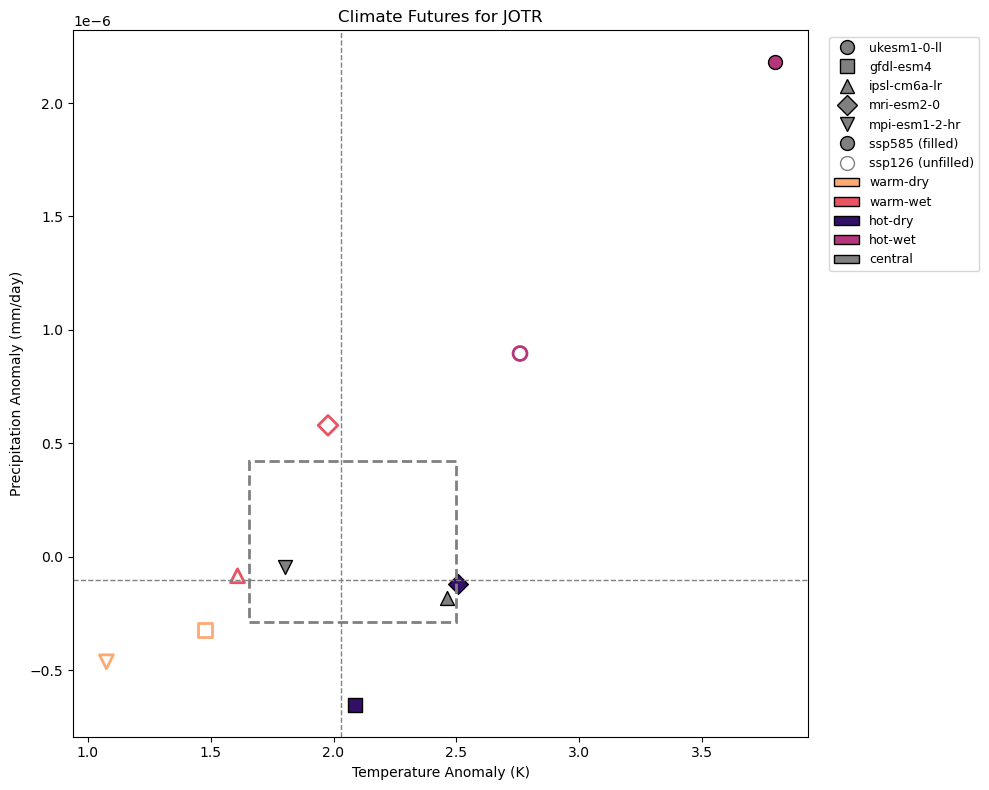

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

def plot_climate_futures_quadrant(scenarios=['ssp126', 'ssp585']):
    """
    Plot climate futures quadrant diagram.
    
    Parameters:
    -----------
    scenarios : list
        List of scenarios to plot (default: ['ssp126', 'ssp585'])
    """
    # Use your color scheme
    future_colors = {
        'warm-dry': '#fea973',   # lighter
        'warm-wet': '#e95462',   # medium
        'hot-dry': '#331067',    # darker
        'hot-wet': '#b5367a',    # darkest
        'central': 'gray'
    }
    
    # Markers for models
    model_markers = {'ukesm1-0-ll_r1i1p1f2': 'o', 'gfdl-esm4_r1i1p1f1': 's', 'ipsl-cm6a-lr_r1i1p1f1': '^', 
                     'mri-esm2-0_r1i1p1f1': 'D', 'mpi-esm1-2-hr_r1i1p1f1': 'v'}
    
    # Calculate median for quadrant dividing lines
    median_tas = df['anomaly_tas'].median()
    median_pr = df['anomaly_pr'].median()
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot points by model and scenario, colored by quadrant
    for model in df['model'].unique():
        for scenario in scenarios:
            subset = df[(df['model'] == model) & (df['scenario'] == scenario)]
            if len(subset) > 0:
                for future in subset['climate_future'].unique():
                    future_subset = subset[subset['climate_future'] == future]
                    color = future_colors.get(future, 'gray')
                    # Filled for ssp585, unfilled for ssp126
                    if scenario == 'ssp585':
                        ax.scatter(future_subset['anomaly_tas'], future_subset['anomaly_pr'],
                                  marker=model_markers.get(model, 'o'), 
                                  facecolor=color, edgecolor='k',
                                  s=100, alpha=1, linewidth=1)
                    else:
                        ax.scatter(future_subset['anomaly_tas'], future_subset['anomaly_pr'],
                                  marker=model_markers.get(model, 'o'), 
                                  facecolor='none', edgecolor=color,
                                  s=100, alpha=1, linewidth=2)
    
    # Draw central tendency box (25th-75th percentile)
    ax.add_patch(patches.Rectangle((quantiles.loc[0.25, 'anomaly_tas'], quantiles.loc[0.25, 'anomaly_pr']), 
                                   quantiles.loc[0.75, 'anomaly_tas'] - quantiles.loc[0.25, 'anomaly_tas'], 
                                   quantiles.loc[0.75, 'anomaly_pr'] - quantiles.loc[0.25, 'anomaly_pr'],
                                   linewidth=2, edgecolor='gray', facecolor='none', linestyle='--'))
    
    # Add median lines (0.5 quantile) - divides L-shaped quadrants
    ax.axvline(median_tas, color='gray', linestyle='--', alpha=1, linewidth=1)
    ax.axhline(median_pr, color='gray', linestyle='--', alpha=1, linewidth=1)
    
    # Labels
    ax.set_xlabel('Temperature Anomaly (K)')
    ax.set_ylabel('Precipitation Anomaly (mm/day)')
    ax.set_title(f'Climate Futures for {park.upper()}')
    
    # Create legend
    legend_elements = []
    # Models
    for model, marker in model_markers.items():
        legend_elements.append(Line2D([0], [0], marker=marker, color='w', markerfacecolor='gray',
                                      markersize=10, label=model.split('_')[0], markeredgecolor='k'))
    # Scenarios
    legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                                  markersize=10, label='ssp585 (filled)', markeredgecolor='k'))
    legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                                  markersize=10, label='ssp126 (unfilled)', markeredgecolor='gray', fillstyle='none'))
    # Quadrants
    for future, color in future_colors.items():
        legend_elements.append(patches.Patch(facecolor=color, edgecolor='k', alpha=1, label=future))
    
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_climate_futures_quadrant(scenarios=['ssp370', 'ssp585'])


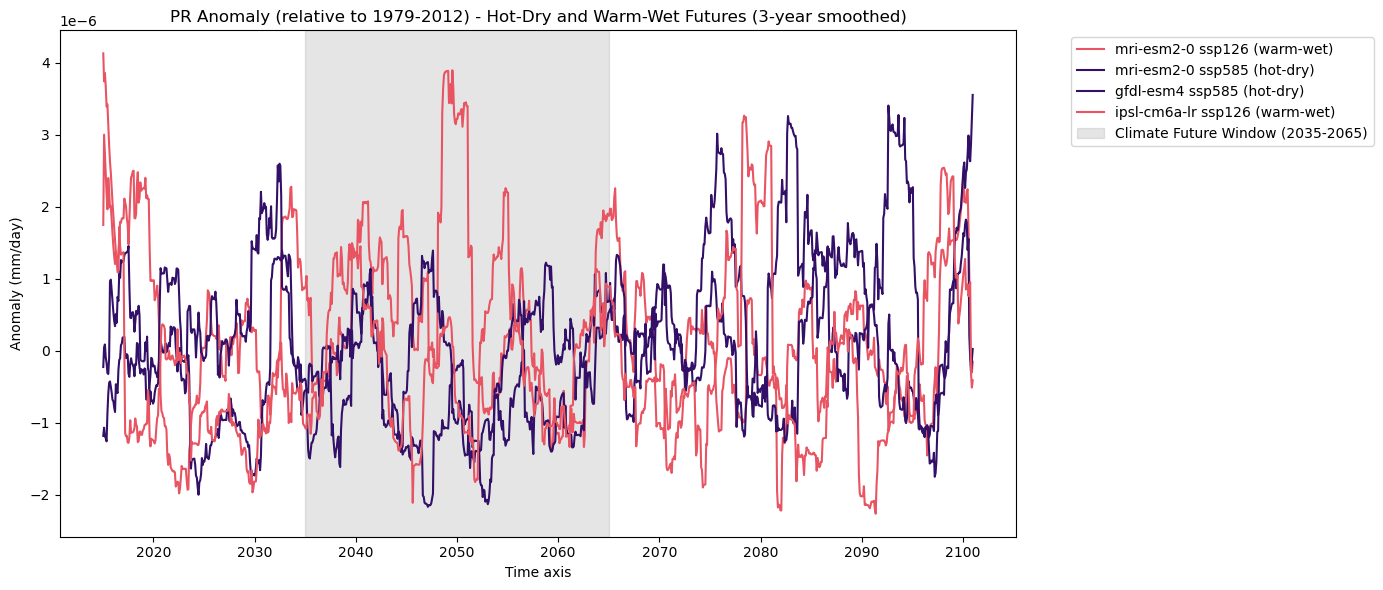

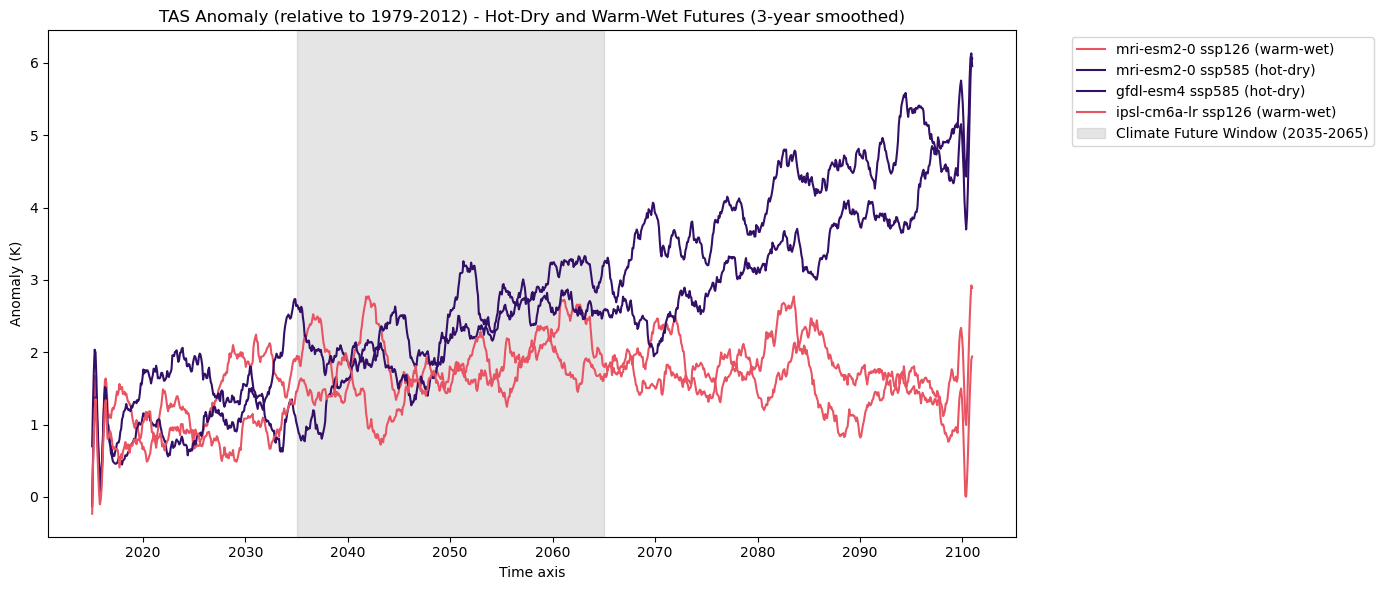

In [69]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_climate_futures_timeseries(variable, ylabel, futures=['hot-dry', 'warm-wet']):
    """
    Plot time series for specified climate futures.
    
    Parameters:
    -----------
    variable : str
        Variable to plot ('pr' for precipitation, 'tas' for temperature)
    ylabel : str
        Label for y-axis
    futures : list
        List of climate futures to plot (default: ['hot-dry', 'warm-wet'])
    """
    # Use your color scheme
    future_colors = {
        'warm-wet': '#e95462',   # medium
        'hot-dry': '#331067'     # darker
    }
    
    # Identify which models are in the specified futures
    models_to_plot = set()
    for future in futures:
        models_to_plot.update(df[(df['climate_future'] == future) & (df['scenario'] != 'historical')]['model'].unique())
    
    # Create time series plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot data for models in specified futures
    for model in models_to_plot:
        for scenario in ['ssp126', 'ssp585']:
            subset = df[(df['model'] == model) & (df['scenario'] == scenario)]
            if len(subset) > 0:
                climate_future = subset['climate_future'].iloc[0]
                
                if climate_future in futures:
                    color = future_colors.get(climate_future, 'gray')
                    
                    try:
                        anomaly = calculate_anomaly(scenario, ("1979", "2012"), model, variable, boundary)
                        # Apply 3-year rolling mean (36 months for monthly data)
                        anomaly_smooth = anomaly.rolling(time=36, center=True, min_periods=1).mean()
                        anomaly_smooth.plot(ax=ax, label=f"{model.split('_')[0]} {scenario} ({climate_future})", 
                                          color=color, alpha=1, linewidth=1.5)
                    except FileNotFoundError:
                        print(f"File not found: {model} {scenario}")
    
    # Add grey box for the time window used to calculate climate future (2035-2065)
    ax.axvspan('2035', '2065', color='gray', alpha=0.2, label='Climate Future Window (2035-2065)')
    
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_title(f'{variable.upper()} Anomaly (relative to 1979-2012) - Hot-Dry and Warm-Wet Futures (3-year smoothed)')
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# Plot precipitation
plot_climate_futures_timeseries('pr', 'Anomaly (mm/day)')

# Plot temperature
plot_climate_futures_timeseries('tas', 'Anomaly (K)')

